In [18]:
# import packages

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import folium
import branca.colormap as cm

In [19]:
# load data from downloaded .csv file 

data = pd.read_csv('/Users/corymckenzie/Desktop/visualization/02_activities/Assignment_3/toronto-beaches-observations.csv')

In [20]:
# display first 10 rows of data 

data.head(10)

,_id,dataCollectionDate,beachName,windSpeed,windDirection,airTemp,rain,rainAmount,waterTemp,waterFowl,waveAction,waterClarity,turbidity
0,1,2010-08-03,Marie Curtis Park East Beach,5.0,SW,31.0,Yes,NaN,22.6,12.0,LOW,Clear,0.9
1,2,2010-08-03,Sunnyside Beach,5.0,SW,31.0,Yes,NaN,21.9,30.0,LOW,Clear,0.6
2,3,2010-08-03,Hanlan's Point Beach,5.0,SW,31.0,Yes,NaN,24.3,20.0,LOW,Clear,0.1
3,4,2010-08-03,Gibraltar Point Beach,5.0,SW,31.0,Yes,NaN,21.3,12.0,LOW,Clear,NaN
4,5,2010-08-03,Centre Island Beach,5.0,SW,31.0,Yes,NaN,21.3,30.0,LOW,Clear,0.2
5,6,2010-08-03,Ward's Island Beach,5.0,SW,31.0,Yes,NaN,21.4,NaN,LOW,Clear,0.6
6,7,2010-08-03,Cherry Beach,10.0,SW,30.0,Yes,NaN,21.3,10.0,LOW,Clear,1.3
7,8,2010-08-03,Woodbine Beaches,10.0,SW,30.0,Yes,NaN,21.5,60.0,LOW,Semi Clear,1.8
8,9,2010-08-03,Kew Balmy Beach,10.0,SW,30.0,Yes,NaN,22.0,50.0,LOW,Semi Clear,2.0
9,10,2010-08-03,Bluffer's Beach Park,10.0,SW,30.0,Yes,NaN,21.8,85.0,LOW,Clear,1.9


In [21]:
# can use this to look at different graph styles

#plt.style.available

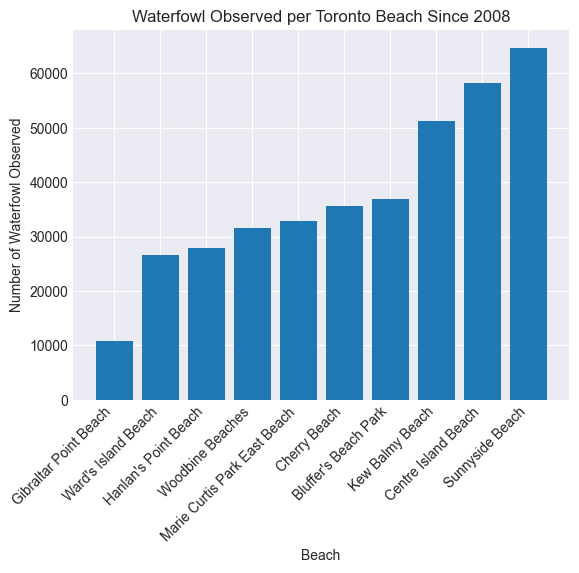

In [22]:
# plot waterfowl observation as a bar graph will all observations for each beach

# organize data by beach and sum the watercowl observations for each beach
count_by_group = data.groupby('beachName')['waterFowl'].sum().sort_values()

# select style 
plt.style.use('seaborn-v0_8-darkgrid')

# plot bar graph 
plt.figure()
plt.bar(count_by_group.index, count_by_group.values)
plt.xlabel('Beach')
plt.ylabel('Number of Waterfowl Observed')
plt.title('Waterfowl Observed per Toronto Beach Since 2008')
plt.xticks(rotation=45, ha='right')
plt.show()

In [23]:
# print out the exact values to use for map
count_by_group

beachName
Gibraltar Point Beach           10865.0
Ward's Island Beach             26524.0
Hanlan's Point Beach            27956.0
Woodbine Beaches                31584.0
Marie Curtis Park East Beach    32799.0
Cherry Beach                    35700.0
Bluffer's Beach Park            36832.0
Kew Balmy Beach                 51216.0
Centre Island Beach             58311.0
Sunnyside Beach                 64729.0
Name: waterFowl, dtype: float64

In [24]:
# create map based visualiztion of waterfowl obervations per beach


# Beach name, latitude, longitude, value (from count_by_group)
beaches = [
    ("Woodbine Beach", 43.66184, -79.30703, 31584),
    ("Kew-Balmy Beach", 43.66687, -79.29447, 51216),
    ("Cherry Beach", 43.63697, -79.34395, 35700),
    ("Sunnyside Beach", 43.6375, -79.4517, 64729),
    ("Hanlan's Point Beach", 43.61975, -79.39429, 27956),
    ("Gibraltar Point Beach", 43.61251, -79.38199, 10865),
    ("Ward's Island Beach", 43.62998, -79.35225, 26524),
    ("Marie Curtis Park East Beach", 43.5853, -79.5446, 32799),
    ("Bluffer's Beach Park", 43.71370, -79.22629, 36832),
    ("Centre Island Beach", 43.61586, -79.37422, 58311)
]

# add title as a text box on the lower left 

#title = """
    # <h3 align="center" style="font-size:20px"><b>Water Fowl Observed per Toronto Beach Since 2010</b></h3>
#"""
title = """
<div style="
    position: fixed;
    bottom: 20px;
    left: 20px;
    z-index:9999;
    background-color: white;
    padding: 6px 12px;
    border-radius: 6px;
    box-shadow: 0 0 6px rgba(0,0,0,0.3);
    font-size: 13px;   /* ~30% smaller than 18px */
    font-weight: bold;
">
Waterfowl Observed per Toronto Beach Since 2008
</div>
"""


# create minimalist style base map
m = folium.Map(
    location=[43.6532, -79.3832],
    zoom_start=12,
    tiles="CartoDB positron"
)

# color scale for data points
colormap = cm.LinearColormap(
    colors=["blue", "green", "yellow", "red"],
    vmin=10000,
    vmax=70000,
    caption="Number of Waterfowl Observed"
)

# add data point that scale their size based on muber of observations
for beach, lat, lon, value in beaches:
    folium.CircleMarker(
        location=[lat, lon],
        radius=5 + (value - 10000) / 5000,  # scale size
        color=colormap(value),
        fill=True,
        fill_color=colormap(value),
        fill_opacity=0.9,
        popup=f"<b>{beach}</b><br>Waterfowl Observed: {value}",
        tooltip=f"{beach}: {value}"
    ).add_to(m)

# add legend
colormap.add_to(m)

# add title
m.get_root().html.add_child(folium.Element(title))

# display map
m

In [25]:
# save the vidualization as an interactive html file

#m.save("Visualization_1.html")